## Load Dataset

### Subtask:
Load the 'tips' dataset from the seaborn library into a pandas DataFrame.

In [44]:
import seaborn as sns # Import seaborn for dataset loading
import pandas as pd     # Import pandas for data manipulation

# Load the 'tips' dataset from the seaborn library
df = sns.load_dataset('tips')

# Print a confirmation message and display the first 5 rows of the DataFrame
print("Dataset 'tips' loaded successfully into DataFrame 'df'.")
print("\nFirst 5 rows of the 'tips' dataset:")
display(df.head())

# Print information about the DataFrame, including data types and non-null counts
print("\nInformation about the 'tips' dataset:")
df.info()

Dataset 'tips' loaded successfully into DataFrame 'df'.

First 5 rows of the 'tips' dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Information about the 'tips' dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## Prepare Data

### Subtask:
Define the feature variables (X) and the target variable (y). Split the dataset into training and testing sets. I'll also handle any necessary data preprocessing such as missing value imputation or one-hot encoding for categorical features based on the chosen dataset.

In [45]:
from sklearn.model_selection import train_test_split # Import for splitting data
import pandas as pd # Import pandas for data manipulation, if not already imported

# 1. Define the target variable (y) as 'tip' from the DataFrame
y = df['tip']

# 2. Define the feature variables (X) by dropping the 'tip' column from the DataFrame
X = df.drop('tip', axis=1)

# 3. Identify categorical features in the dataset for one-hot encoding
categorical_cols = ['sex', 'smoker', 'day', 'time']

# 4. Apply one-hot encoding to the identified categorical features in X
# drop_first=True avoids multicollinearity by dropping the first category in each feature
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features (X) and target (y) defined and categorical features one-hot encoded.")
print("Shape of X after encoding:", X.shape)
print("First 5 rows of X after encoding:")
display(X.head())

# 5. Split the preprocessed data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}") # Display shape of training features
print(f"X_test shape: {X_test.shape}")   # Display shape of testing features
print(f"y_train shape: {y_train.shape}") # Display shape of training target
print(f"y_test shape: {y_test.shape}")     # Display shape of testing target

Features (X) and target (y) defined and categorical features one-hot encoded.
Shape of X after encoding: (244, 8)
First 5 rows of X after encoding:


,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2,True,True,False,False,True,True
1,10.34,3,False,True,False,False,True,True
2,21.01,3,False,True,False,False,True,True
3,23.68,2,False,True,False,False,True,True
4,24.59,4,True,True,False,False,True,True



Dataset split into training and testing sets.
X_train shape: (195, 8)
X_test shape: (49, 8)
y_train shape: (195,)
y_test shape: (49,)


## Train Decision Tree Regressor

### Subtask:
Initialize and train a Decision Tree Regressor model on the training data.

In [46]:
from sklearn.tree import DecisionTreeRegressor # Import the Decision Tree Regressor model

# Initialize the Decision Tree Regressor model with a fixed random state for reproducibility
dt_regressor = DecisionTreeRegressor(random_state=42)

# Fit (train) the model to the training data (features X_train and target y_train)
dt_regressor.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


## Evaluate Model Performance

### Subtask:
Make predictions on the test set and evaluate the model's performance using relevant regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Import evaluation metrics

# 1. Make predictions on the test set using the trained Decision Tree Regressor
y_pred = dt_regressor.predict(X_test)

# 2. Calculate evaluation metrics to assess the model's performance
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)   # Mean Squared Error
r2 = r2_score(y_test, y_pred)               # R-squared score

# 3. Print the calculated evaluation metrics, formatted to two decimal places
print(f"Model Performance Evaluation:\n")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Model Performance Evaluation:

Mean Absolute Error (MAE): 0.76
Mean Squared Error (MSE): 0.97
R-squared (R2): 0.22


## Visualize Predictions

### Subtask:
Generate a scatter plot to visualize the actual versus predicted values from the Decision Tree Regressor model, including appropriate labels and a legend.

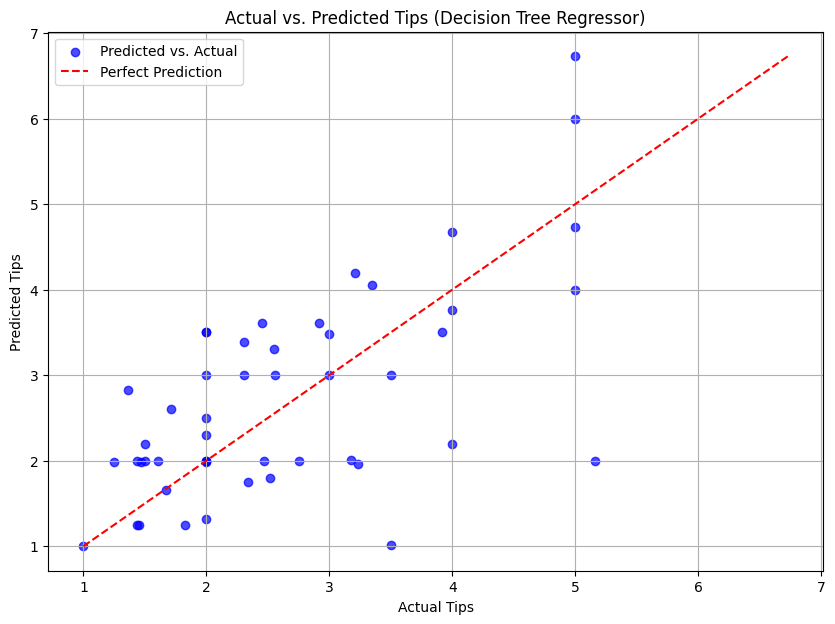

Scatter plot of Actual vs. Predicted Tips displayed.


In [48]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Create a new figure with a specified size for the plot
plt.figure(figsize=(10, 7))

# Create a scatter plot of actual vs. predicted values
# y_test are the true values, y_pred are the model's predictions
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predicted vs. Actual')

# Add a line representing perfect predictions (where predicted = actual)
# Determine the range for the diagonal line based on min/max of actual and predicted values
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Set the title and labels for the axes
plt.title('Actual vs. Predicted Tips (Decision Tree Regressor)')
plt.xlabel('Actual Tips')
plt.ylabel('Predicted Tips')

# Add a legend to distinguish between scatter points and the perfect prediction line
plt.legend()
# Add a grid for better readability
plt.grid(True)
# Display the plot
plt.show()

print("Scatter plot of Actual vs. Predicted Tips displayed.")

## Final Task

### Subtask:
Summarize the findings from the Decision Tree Regression model, including key performance metrics and insights from the visualization.

## Summary:

### Q&A
For this task, the 'tips' dataset from Seaborn was used to demonstrate Decision Tree Regression.

### Data Analysis Key Findings
*   The 'tips' dataset was successfully loaded, containing information about total bill, tip, sex, smoker status, day, time, and size of the party.
*   The data was preprocessed by defining 'tip' as the target variable (y) and the remaining columns as features (X). Categorical features ('sex', 'smoker', 'day', 'time') were one-hot encoded.
*   The dataset was split into training (195 samples) and testing (49 samples) sets, with 80% for training and 20% for testing.
*   A Decision Tree Regressor model was initialized with `random_state=42` and successfully trained on the preprocessed training data.
*   Upon evaluation on the test set, the model achieved the following performance metrics:
    *   **Mean Absolute Error (MAE):** 0.76
    *   **Mean Squared Error (MSE):** 0.97
    *   **R-squared (R2):** 0.22
*   The scatter plot of actual vs. predicted tips showed that while there's a general positive trend, the predictions are not perfectly aligned with the actual values. The model tends to predict values within a certain range, but with noticeable spread around the perfect prediction line.

### Insights or Next Steps
*   An R-squared value of 0.22 indicates that the Decision Tree Regressor explains only about 22% of the variance in tip amounts. This suggests that the model's predictive power is limited for this dataset, and there's significant room for improvement.
*   The MAE of 0.76 means that, on average, the model's predictions are off by about $0.76 from the actual tip amount.
*   To improve model performance, consider the following next steps:
    *   **Hyperparameter Tuning:** Experiment with different hyperparameters for the Decision Tree Regressor (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`) to find an optimal configuration.
    *   **Feature Engineering:** Create new features from existing ones that might have more predictive power (e.g., tip percentage).
    *   **Alternative Models:** Explore other regression models such as Random Forest, Gradient Boosting, or even linear models, which might be more suitable for this dataset.
    *   **Interaction Terms:** Investigate if interactions between features (e.g., `total_bill` and `size`) could improve predictions.